Sample Records:
    CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


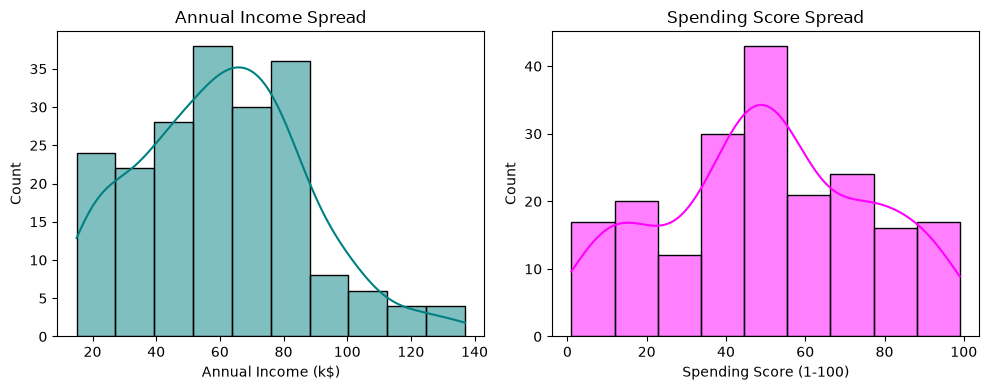

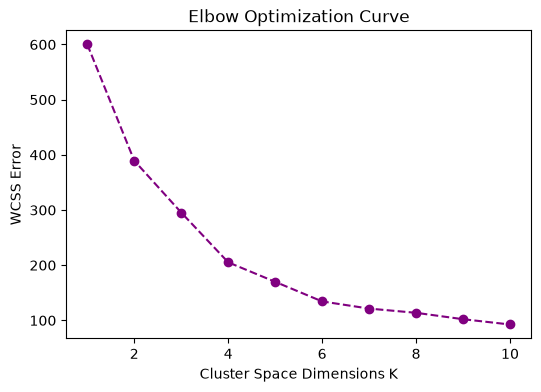

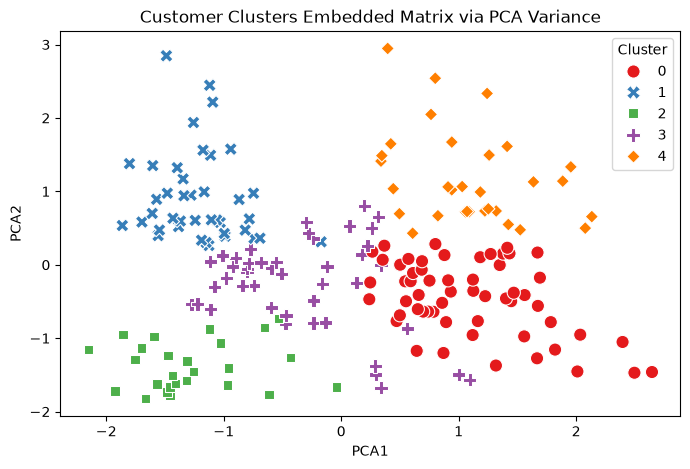


--- Strategic Behavioral Group Benchmarks ---
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        55.275862           47.620690               41.706897
1        32.875000           86.100000               81.525000
2        25.769231           26.115385               74.846154
3        26.733333           54.311111               40.911111
4        44.387097           89.774194               18.483871


In [1]:
# ==============================================================================
# PROBLEM STATEMENT & OBJECTIVE
# Cluster retail mall clients by financial behavior to derive targeted marketing strategies.
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Load Data
df = pd.read_csv('Mall_Customers (1).csv')
print("Sample Records:\n", df.head())

# 2. Exploratory Data Analysis (EDA)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['Annual Income (k$)'], kde=True, color='teal')
plt.title('Annual Income Spread')

plt.subplot(1, 2, 2)
sns.histplot(df['Spending Score (1-100)'], kde=True, color='magenta')
plt.title('Spending Score Spread')
plt.tight_layout()
plt.show()

# 3. Scaling Segment Attributes
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. WCSS Optimization (Elbow Method)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(range(1, 11), wcss, marker='o', color='purple', linestyle='--')
plt.title('Elbow Optimization Curve')
plt.xlabel('Cluster Space Dimensions K')
plt.ylabel('WCSS Error')
plt.show()

# 5. Model Execution with Optimal Clusters (K=5)
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 6. Dimensionality Reduction Dimensional Plotting (PCA)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster', palette='Set1', style='Cluster', s=90)
plt.title('Customer Clusters Embedded Matrix via PCA Variance')
plt.show()

# 7. Segment Profiles Overview
print("\n--- Strategic Behavioral Group Benchmarks ---")
print(df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean())